# Trafik kazası riskini tahmin etmek

In [1]:
import os, pandas as pd, numpy as np, tensorflow as tf
from sklearn.preprocessing import StandardScaler
warnings = __import__('warnings').filterwarnings('ignore')

In [2]:
train =pd.read_csv('train.csv')
test =pd.read_csv('test.csv')


In [3]:
train

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [4]:
test

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172580,690334,rural,2,0.01,45,dim,rainy,False,False,afternoon,True,True,2
172581,690335,rural,1,0.74,70,daylight,foggy,False,True,afternoon,False,False,2
172582,690336,urban,2,0.14,70,dim,clear,False,False,evening,True,True,1
172583,690337,urban,1,0.09,45,daylight,foggy,True,True,morning,False,True,0


In [5]:
train.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [7]:
HEDEF='accident_risk'

In [8]:
# feature engineer (Kritik Tehlike Endeksleri)
# Eğer veri setinde bu standart sürüş güvenliği sütunları varsa etkileşimleri türetir
for df in [train, test]:
    # Hız limiti ve yol koşullarının birleşik tehlike etkisi
    speed_col = [c for c in df.columns if 'speed' in c.lower()]
    weather_col = [c for c in df.columns if 'weather' in c.lower() or 'condition' in c.lower()]
    if speed_col and weather_col:
        df['critical_hazard_index'] = df[speed_col[0]] * df[weather_col[0]].astype('category').cat.codes


In [9]:
# Metinleri Sayısallaştırma ve Girdileri Ayırma
all_data = pd.get_dummies(pd.concat([train.drop(['id', HEDEF], axis=1, errors='ignore'), test.drop(['id'], axis=1, errors='ignore')]), drop_first=True).fillna(0)
x_train, x_test = all_data.iloc[:len(train)], all_data.iloc[len(train):]
y_train = train[HEDEF].values

In [10]:
# Giriş Verilerini Normalize Etme
scaler = StandardScaler()
x_train_scaled, x_test_scaled = scaler.fit_transform(x_train), scaler.transform(x_test)


In [11]:
# Keras Regresyon Modeli
model = tf.keras.Sequential([
    # .shape[1] ekleyerek sadece özellik sütun sayısını (17) içeri gönderiyoruz
    tf.keras.layers.Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1) # Kaza risk skoru tahmini için tek nöronlu doğrusal çıktı
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [12]:
model.fit(x_train_scaled, y_train, epochs=20, batch_size=512, validation_split=0.1, verbose=1)


Epoch 1/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0172 - mae: 0.0929 - val_loss: 0.0053 - val_mae: 0.0573
Epoch 2/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0056 - mae: 0.0586 - val_loss: 0.0043 - val_mae: 0.0511
Epoch 3/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0043 - mae: 0.0512 - val_loss: 0.0036 - val_mae: 0.0469
Epoch 4/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0038 - mae: 0.0477 - val_loss: 0.0034 - val_mae: 0.0455
Epoch 5/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0036 - mae: 0.0468 - val_loss: 0.0034 - val_mae: 0.0457
Epoch 6/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0035 - mae: 0.0461 - val_loss: 0.0033 - val_mae: 0.0449
Epoch 7/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0035 - mae: 0.0457 - val_loss: 0.0033 - val_mae: 0.0449
Epoch 8/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0034 - mae: 0.0455 - val_loss: 0.0034 - val_mae: 0.0450
Epoch 9/20
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - lo

<Axes: >

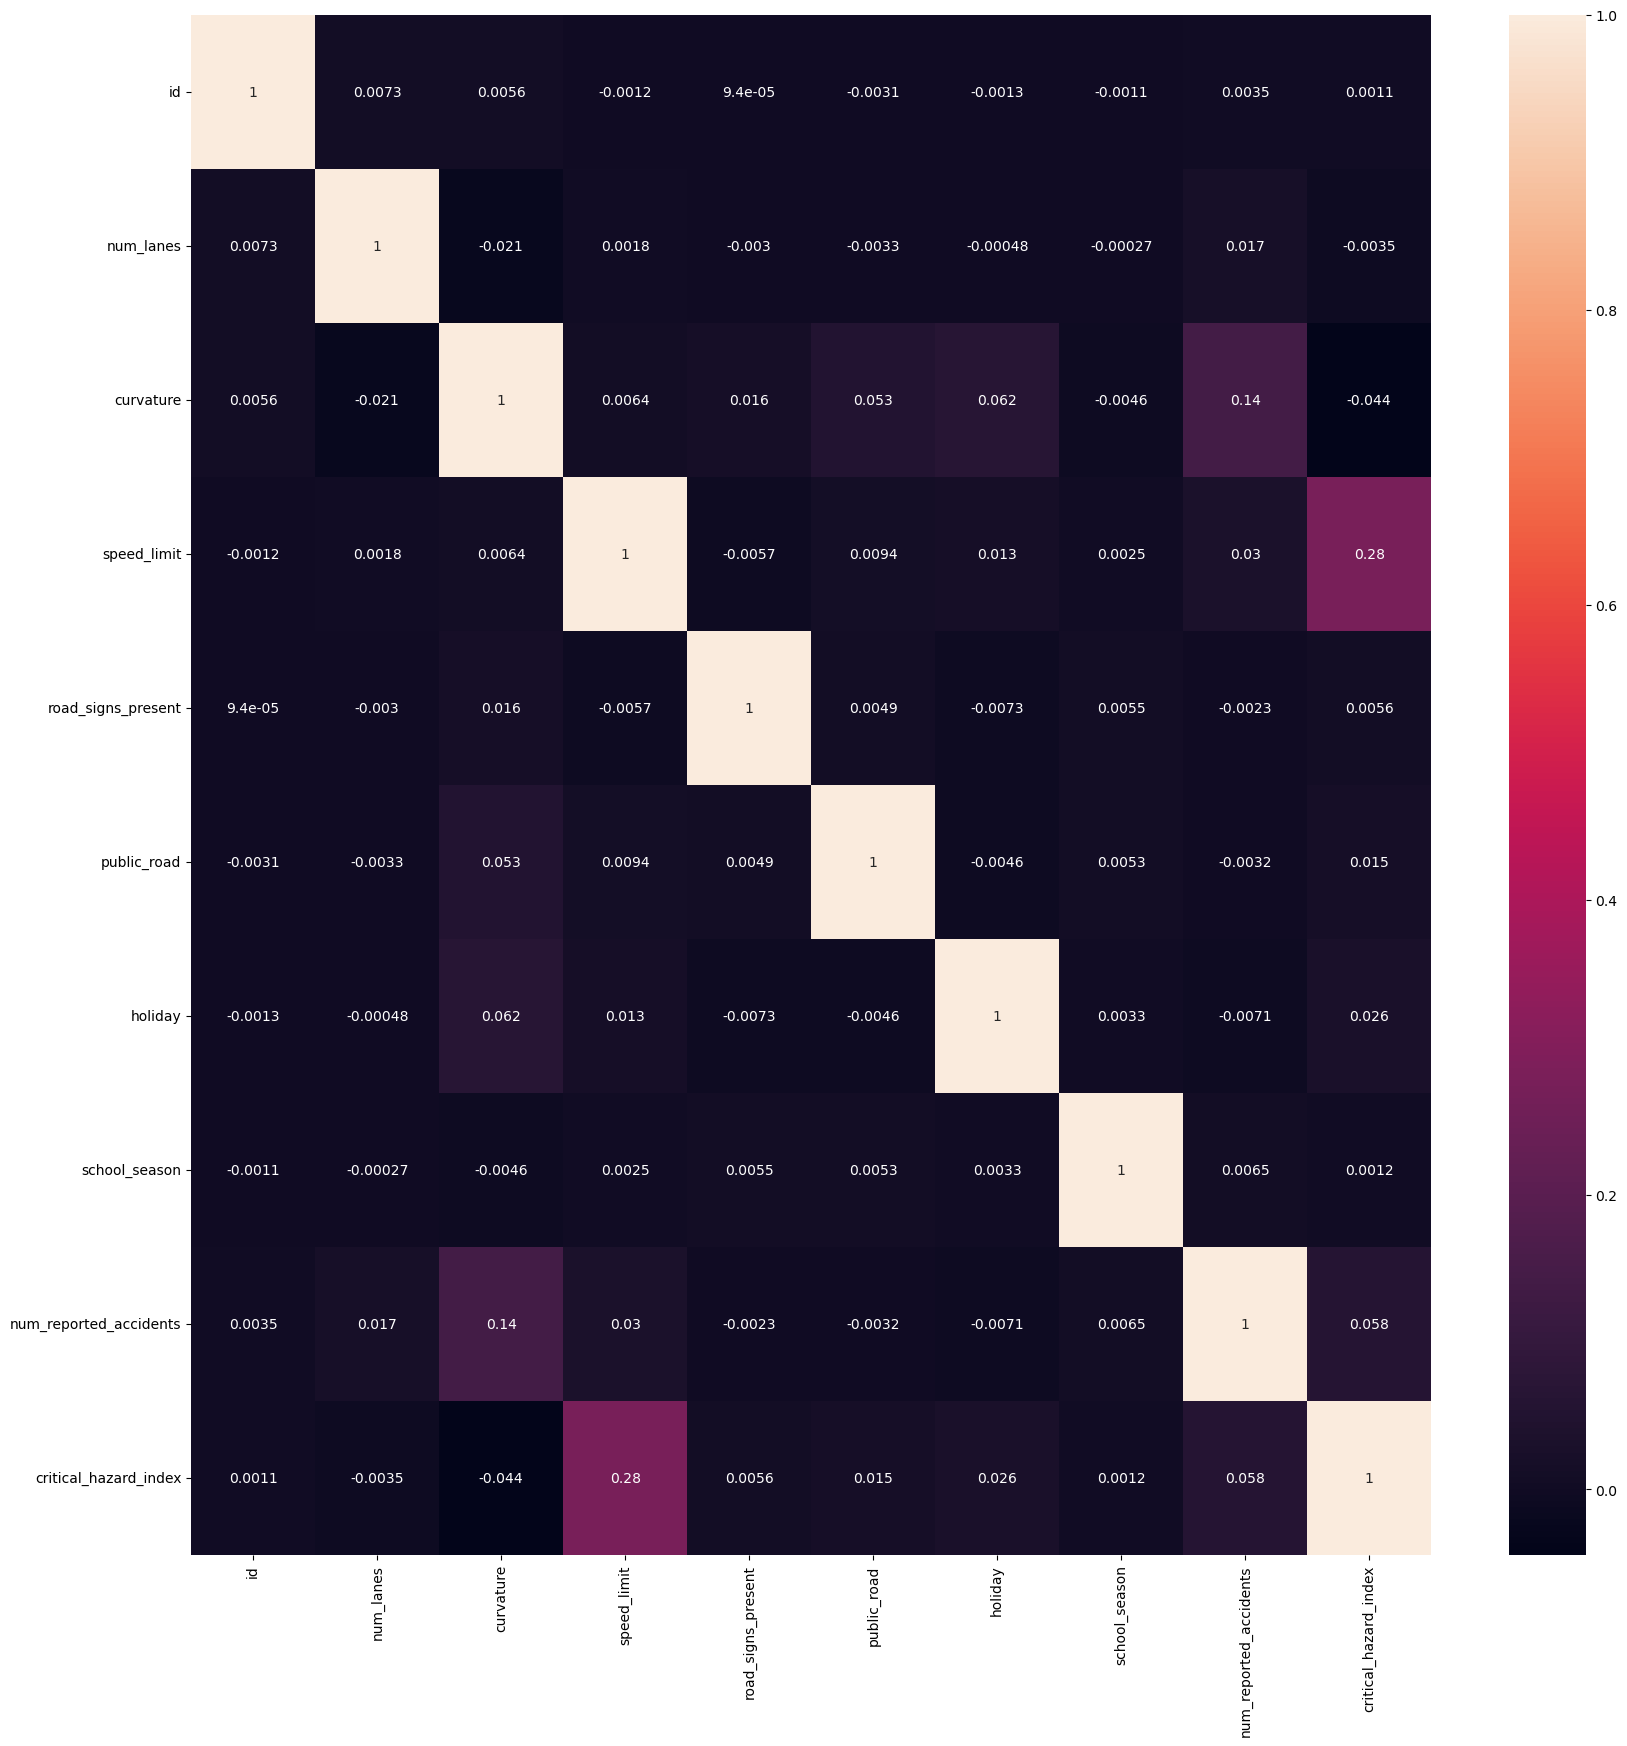

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [15]:
# Tahminleri Üretme ve Kaggle Gönderi Dosyası Hazırlama
preds = model.predict(x_test_scaled).flatten()

5394/5394 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


In [16]:
submission = pd.DataFrame({'id': test['id'], HEDEF: preds})

In [17]:
submission.to_csv('submission.csv', index=False)